# TT-06 — NAIVE BAYES: LỌC TIN NHẮN RÁC CHO TỔNG ĐÀI VIỄN THÔNG
**Khoá học:** HỌC MÁY · [Buổi 8 (NLP)](https://github.com/TruongTanNghia/Training-Machine-learning/tree/main/Buoi-08-NLP)  
**Nhóm thuật toán:** Phân loại xác suất · Xử lý ngôn ngữ tự nhiên (NLP)  
**Thuật toán:** Multinomial Naive Bayes / Bernoulli Naive Bayes  
**Lĩnh vực:** Viễn thông · An ninh thông tin & Chống gian lận  
**Thời lượng dự kiến:** 4–6 giờ | **Độ khó:** ⭐⭐

---

## 1. TỔNG QUAN BÀI TOÁN & CƠ SỞ TOÁN HỌC

### 1.1. Bài toán thực tế trong ngành viễn thông
Một nhà mạng viễn thông tiếp nhận khoảng **50 triệu tin nhắn SMS mỗi ngày**. Để bảo vệ người dùng khỏi lừa đảo và tin rác, hệ thống gateway cần phân loại và chặn tin rác theo thời gian thực:
* **Thời gian xử lý cho phép:** $< 5$ mili-giây / tin nhắn.
* **Chi phí của sai lầm (Cost of Errors):**
  * **False Positive (FP - Chặn nhầm tin thật):** Khách hàng bị mất mã OTP ngân hàng, thông báo chuyến bay, tin khẩn cấp $\rightarrow$ **Khiếu nại nghiêm trọng, tổn hại uy tín nhà mạng**.
  * **False Negative (FN - Lọt tin rác):** Khách hàng nhận phải tin quảng cáo/spam $\rightarrow$ Hơi phiền toái nhưng không gây tê liệt dịch vụ.
* **Mục tiêu kỹ thuật:** **Ưu tiên Precision cực cao ($\ge 0.98$)** trên lớp Spam, chấp nhận Recall có thể thấp hơn.

### 1.2. Cơ sở lý thuyết: Định lý Bayes & Giả định "Ngây thơ"
Theo định lý Bayes, xác suất hậu nghiệm (Posterior) của một văn bản $d = (w_1, w_2, \dots, w_n)$ thuộc lớp $c \in \{\text{ham}, \text{spam}\}$ là:

$$P(c \mid d) = \frac{P(c) \cdot P(d \mid c)}{P(d)} = \frac{P(c) \cdot P(w_1, w_2, \dots, w_n \mid c)}{P(d)}$$

**Giả định "Ngây thơ" (Conditional Independence):**
Các từ trong câu xuất hiện độc lập với nhau với điều kiện đã biết lớp $c$:

$$P(w_1, w_2, \dots, w_n \mid c) \approx \prod_{i=1}^n P(w_i \mid c)$$

Để phân loại, ta chọn lớp có xác suất hậu nghiệm lớn nhất (**Maximum A Posteriori - MAP**):

$$\hat{c} = \arg\max_{c \in \{\text{ham}, \text{spam}\}} \left[ \log P(c) + \sum_{i=1}^n \log P(w_i \mid c) \right]$$

### 1.3. Kỹ thuật làm mượt Laplace Smoothing (Laplace Smoothing)
Nếu một từ $w$ chưa từng xuất hiện trong lớp $c$ ở tập train:
$$P(w \mid c) = 0 \implies \prod_{i=1}^n P(w_i \mid c) = 0$$
Chỉ **một từ lạ** sẽ xóa sạch toàn bộ tích xác suất của văn bản!  
Để khắc phục hiện tượng **Zero Frequency**, ta cộng thêm tham số làm mượt $\alpha > 0$:

$$P(w_i \mid c) = \frac{\text{count}(w_i, c) + \alpha}{\sum_{w' \in V} \text{count}(w', c) + \alpha \cdot |V|}$$

* $\alpha = 1.0$: Laplace Smoothing chuẩn.
* $\alpha = 0.1$: Ít làm mượt hơn, thường tối ưu cho từ vựng lớn.
* $\alpha = 0.0$: **TUYỆT ĐỐI KHÔNG DÙNG** trong thực tế do gặp lỗi chia 0 và xác suất 0.


---
## BƯỚC 1: CÀI ĐẶT THƯ VIỆN & NẠP DỮ LIỆU

> **Cạm bẫy Encoding:** Tập dữ liệu SMS Spam Collection nguyên bản từ UCI/Kaggle được mã hoá theo chuẩn `latin-1` (Windows-1252), chứa các ký tự tiền tệ như `£`, `€`, `...`. Nếu dùng `encoding='utf-8'` mặc định của Pandas, chương trình sẽ báo lỗi `UnicodeDecodeError`.


In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, precision_recall_curve, classification_report
)

# Cấu hình đường dẫn và hiển thị
DATA_PATH = os.path.join("..", "data", "spam.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("data", "spam.csv")

REPORT_DIR = os.path.join("..", "reports")
if not os.path.exists(REPORT_DIR):
    REPORT_DIR = "reports"
os.makedirs(REPORT_DIR, exist_ok=True)

MODEL_DIR = os.path.join("..", "models")
if not os.path.exists(MODEL_DIR):
    MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42

print(f"Data path: {DATA_PATH}")


Data path: ..\data\spam.csv


In [2]:
# Nạp dữ liệu với encoding latin-1
df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Chuẩn hoá tên cột
if "v1" in df.columns and "v2" in df.columns:
    df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
else:
    df.columns = ["label", "text"] + list(df.columns[2:])
    df = df[["label", "text"]]

print(f"Tổng số dòng ban đầu: {len(df):,}")
print("\nPhân phối nhãn ban đầu:")
print(df["label"].value_counts())
print(f"\nTỉ lệ spam ban đầu: {(df['label'] == 'spam').mean():.2%}")
df.head(5)


Tổng số dòng ban đầu: 5,572

Phân phối nhãn ban đầu:
label
ham     4825
spam     747
Name: count, dtype: int64

Tỉ lệ spam ban đầu: 13.41%


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


---
## BƯỚC 2: KIỂM TRA & LOẠI BỎ TIN NHẮN TRÙNG LẶP

> **Cạm bẫy Data Leakage:** Trong bài toán Spam, nhiều tin rác được phát tán hàng loạt dẫn đến ~400 tin nhắn trùng nội dung. Nếu không loại bỏ trước khi chia tập dữ liệu, các tin nhắn giống hệt nhau sẽ xuất hiện ở cả tập Train và Test $\rightarrow$ Đánh giá mô hình bị sai lệch và lạc quan thái quá.


In [3]:
n_before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
n_dropped = n_before - len(df)

print(f"Số tin trùng lặp đã loại bỏ : {n_dropped} dòng")
print(f"Số tin nhắn duy nhất còn lại : {len(df):,} dòng")
print("\nPhân phối nhãn sau khi lọc trùng:")
print(df["label"].value_counts())
print(f"\nTỉ lệ spam sau khi lọc trùng: {(df['label'] == 'spam').mean():.2%}")


Số tin trùng lặp đã loại bỏ : 403 dòng
Số tin nhắn duy nhất còn lại : 5,169 dòng

Phân phối nhãn sau khi lọc trùng:
label
ham     4516
spam     653
Name: count, dtype: int64

Tỉ lệ spam sau khi lọc trùng: 12.63%


---
## BƯỚC 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) & CHIA TẬP TRAIN/TEST

### Đặc trưng độ dài tin nhắn (Text Length)
Các tin nhắn rác thường cố gắng nhồi nhét nhiều thông tin mời gọi, link truy cập, cú pháp trúng thưởng, số điện thoại $\rightarrow$ Có xu hướng dài hơn tin nhắn cá nhân thông thường.


In [4]:
df["length"] = df["text"].str.len()
df["num_words"] = df["text"].apply(lambda x: len(x.split()))

print("--- Thống kê độ dài ký tự theo nhãn ---")
print(df.groupby("label")["length"].describe()[["count", "mean", "std", "50%", "min", "max"]])

print("\n--- Thống kê số lượng từ theo nhãn ---")
print(df.groupby("label")["num_words"].describe()[["count", "mean", "std", "50%", "min", "max"]])


--- Thống kê độ dài ký tự theo nhãn ---
        count        mean        std    50%   min    max
label                                                   
ham    4516.0   70.987600  56.736845   53.0   2.0  910.0
spam    653.0  138.130168  29.937254  149.0  13.0  224.0

--- Thống kê số lượng từ theo nhãn ---
        count       mean        std   50%  min    max
label                                                
ham    4516.0  14.239814  11.179471  11.0  1.0  171.0
spam    653.0  23.739663   5.931064  25.0  2.0   35.0


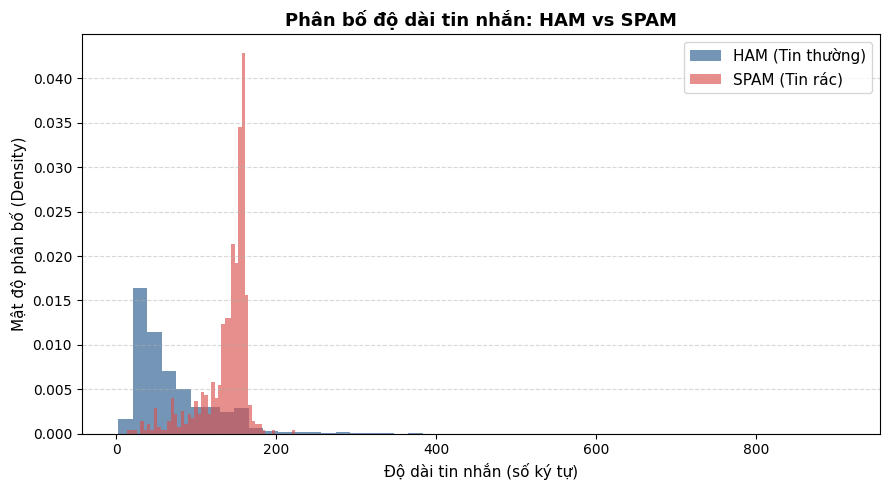

In [5]:
# Trực quan hoá phân bố độ dài
plt.figure(figsize=(9, 5))
plt.hist(df[df["label"] == "ham"]["length"], bins=50, alpha=0.65, label="HAM (Tin thường)", color="#2b5c8f", density=True)
plt.hist(df[df["label"] == "spam"]["length"], bins=50, alpha=0.65, label="SPAM (Tin rác)", color="#d9534f", density=True)
plt.xlabel("Độ dài tin nhắn (số ký tự)", fontsize=11)
plt.ylabel("Mật độ phân bố (Density)", fontsize=11)
plt.title("Phân bố độ dài tin nhắn: HAM vs SPAM", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "do_dai_tin.png"), dpi=150)
plt.show()


In [6]:
# Chia tập Train (80%) và Test (20%) có Stratify để bảo toàn tỉ lệ phân phối
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE
)

print(f"Tập Train : {len(X_train):,} tin nhắn (Spam: {(y_train == 'spam').sum():,}, Ham: {(y_train == 'ham').sum():,})")
print(f"Tập Test  : {len(X_test):,} tin nhắn (Spam: {(y_test == 'spam').sum():,}, Ham: {(y_test == 'ham').sum():,})")


Tập Train : 4,135 tin nhắn (Spam: 522, Ham: 3,613)
Tập Test  : 1,034 tin nhắn (Spam: 131, Ham: 903)


---
## BƯỚC 4: BASELINE MODEL (DUMMY CLASSIFIER)

> **Cạm bẫy Accuracy Paradox:** Với tập dữ liệu mất cân bằng (87% Ham, 13% Spam), một mô hình "ngây ngô" chỉ cần luôn luôn đoán nhãn đa số (`ham`) là đã đạt Accuracy ~87.3%. Tuy nhiên mô hình này **hoàn toàn vô dụng** vì không lọc được bất kỳ tin rác nào.


In [7]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
prec_dummy = precision_score(y_test, y_pred_dummy, pos_label="spam", zero_division=0)
rec_dummy = recall_score(y_test, y_pred_dummy, pos_label="spam", zero_division=0)
f1_dummy = f1_score(y_test, y_pred_dummy, pos_label="spam", zero_division=0)

print(f"Dummy Classifier Metrics:")
print(f"- Accuracy : {acc_dummy:.4f} ({acc_dummy*100:.2f}%)  <-- Ảo tưởng độ chính xác cao!")
print(f"- Precision: {prec_dummy:.4f}")
print(f"- Recall   : {rec_dummy:.4f}")
print(f"- F1-Score : {f1_dummy:.4f}")


Dummy Classifier Metrics:
- Accuracy : 0.8733 (87.33%)  <-- Ảo tưởng độ chính xác cao!
- Precision: 0.0000
- Recall   : 0.0000
- F1-Score : 0.0000


---
## BƯỚC 5-7: SO SÁNH 3 TỔ HỢP VECTOR HOÁ & BIẾN THỂ NAIVE BAYES

Ta so sánh 3 tổ hợp phổ biến trong NLP phân loại văn bản:
1. **CountVectorizer + MultinomialNB:** Đếm tần suất xuất hiện của từ/n-gram.
2. **TfidfVectorizer + MultinomialNB:** Sử dụng trọng số TF-IDF để giảm bớt ảnh hưởng của các từ quá phổ biến.
3. **TfidfVectorizer + BernoulliNB:** Chỉ quan tâm đến việc từ có xuất hiện hay không (Binary / Boolean occurrence). Với tin nhắn SMS rất ngắn, BernoulliNB thường hoạt động đặc biệt hiệu quả.

> **Quy tắc vàng:** `fit_transform` chỉ được thực hiện trên tập Train. Trên tập Test chỉ được gọi `transform` (được đảm bảo tự động thông qua `Pipeline`).


In [8]:
combos = {
    "CountVectorizer + MultinomialNB": make_pipeline(
        CountVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9),
        MultinomialNB(alpha=0.1),
    ),
    "TfidfVectorizer + MultinomialNB": make_pipeline(
        TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
        MultinomialNB(alpha=0.1),
    ),
    "TfidfVectorizer + BernoulliNB": make_pipeline(
        TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
        BernoulliNB(alpha=0.1),
    ),
}

results = []
fitted_models = {}

for name, pipe in combos.items():
    # Đo thời gian huấn luyện
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # Đo thời gian dự đoán trung bình mỗi tin nhắn
    t0 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    predict_time_total = time.perf_counter() - t0
    predict_ms_per_msg = (predict_time_total / len(X_test)) * 1000

    prec = precision_score(y_test, y_pred, pos_label="spam")
    rec = recall_score(y_test, y_pred, pos_label="spam")
    f1 = f1_score(y_test, y_pred, pos_label="spam")
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Tổ hợp": name,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4),
        "Accuracy": round(acc, 4),
        "Train Time (s)": round(train_time, 4),
        "Predict Time (ms/tin)": round(predict_ms_per_msg, 4),
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False)
results_df.to_csv(os.path.join(REPORT_DIR, "bang_so_sanh_3_to_hop.csv"), index=False)
results_df


,Tổ hợp,Precision,Recall,F1-score,Accuracy,Train Time (s),Predict Time (ms/tin)
2,TfidfVectorizer + BernoulliNB,1.0000,0.8702,0.9306,0.9836,0.2865,0.0616
1,TfidfVectorizer + MultinomialNB,0.9669,0.8931,0.9286,0.9826,0.3539,0.0588
0,CountVectorizer + MultinomialNB,0.9370,0.9084,0.9225,0.9807,0.3279,0.0592


---
## BƯỚC 8: DÒ SIÊU THAM SỐ ($lpha$, N-GRAM) & HIỂU VỀ LAPLACE SMOOTHING

### 8.1. Dò tham số $lpha \in \{0.01, 0.1, 0.5, 1.0\}$ và `ngram_range` $\in \{(1, 1), (1, 2)\}$


In [9]:
grid_results = []
for alpha in [0.01, 0.1, 0.5, 1.0]:
    for ngram in [(1, 1), (1, 2)]:
        pipe = make_pipeline(
            TfidfVectorizer(lowercase=True, ngram_range=ngram, min_df=2, max_df=0.9, sublinear_tf=True),
            MultinomialNB(alpha=alpha),
        )
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        grid_results.append({
            "alpha": alpha,
            "ngram_range": str(ngram),
            "Precision": round(precision_score(y_test, y_pred, pos_label="spam"), 4),
            "Recall": round(recall_score(y_test, y_pred, pos_label="spam"), 4),
            "F1-score": round(f1_score(y_test, y_pred, pos_label="spam"), 4),
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        })

grid_df = pd.DataFrame(grid_results).sort_values("F1-score", ascending=False)
grid_df.to_csv(os.path.join(REPORT_DIR, "grid_alpha_ngram.csv"), index=False)
grid_df


,alpha,ngram_range,Precision,Recall,F1-score,Accuracy
1,0.01,"(1, 2)",0.9593,0.9008,0.9291,0.9826
3,0.10,"(1, 2)",0.9669,0.8931,0.9286,0.9826
2,0.10,"(1, 1)",0.9512,0.8931,0.9213,0.9807
0,0.01,"(1, 1)",0.9583,0.8779,0.9163,0.9797
4,0.50,"(1, 1)",0.9825,0.8550,0.9143,0.9797
5,0.50,"(1, 2)",1.0000,0.7863,0.8803,0.9729
6,1.00,"(1, 1)",1.0000,0.7557,0.8609,0.9691
7,1.00,"(1, 2)",1.0000,0.7099,0.8304,0.9632


### 8.2. Thực nghiệm minh hoạ: Vì sao $lpha = 0$ làm hỏng mô hình?


In [10]:
# Thử nghiệm với alpha = 0.0 (Zero smoothing)
try:
    demo_pipe = make_pipeline(CountVectorizer(), MultinomialNB(alpha=0.0))
    demo_pipe.fit(X_train, y_train)
    test_msg = ["khuyen mai cuc khung trung thuong 100 trieu chua tung thay bao gio xyz123"]
    probs = demo_pipe.predict_proba(test_msg)
    print("Dự đoán xác suất P(ham), P(spam) khi gặp từ chưa có trong từ điển:")
    print(probs)
except Exception as e:
    print(f"Lỗi phát sinh: {e}")

print("\n[GIẢI THÍCH TOÁN HỌC]:")
print("Khi alpha = 0, nếu từ 'xyz123' chưa từng xuất hiện ở tập train của nhãn Spam,")
print("xác suất P('xyz123' | Spam) = 0 / Total = 0.")
print("Do tính chất nhân tích xác suất trong Naive Bayes, toàn bộ P(Spam | d) = 0.")
print("=> Mô hình hoàn toàn mất khả năng nhận diện!")


Dự đoán xác suất P(ham), P(spam) khi gặp từ chưa có trong từ điển:
[[1. 0.]]

[GIẢI THÍCH TOÁN HỌC]:
Khi alpha = 0, nếu từ 'xyz123' chưa từng xuất hiện ở tập train của nhãn Spam,
xác suất P('xyz123' | Spam) = 0 / Total = 0.
Do tính chất nhân tích xác suất trong Naive Bayes, toàn bộ P(Spam | d) = 0.
=> Mô hình hoàn toàn mất khả năng nhận diện!


---
## BƯỚC 9: TRÍCH XUẤT TOP 20 TỪ ĐẶC TRƯNG CỦA LỚP SPAM

Trong Naive Bayes, `feature_log_prob_[c, i]` đại diện cho $\log P(w_i \mid c)$. Bằng cách trích xuất 20 từ có log xác suất lớn nhất ở lớp `spam`, ta có thể kiểm tra xem mô hình học được các quy luật ngôn ngữ hợp lý trong thực tế hay không.


In [11]:
best_name = results_df.iloc[0]["Tổ hợp"]
best_pipe = fitted_models[best_name]

# Trích xuất vectorizer và classifier
vec = best_pipe.named_steps["tfidfvectorizer"] if "tfidfvectorizer" in best_pipe.named_steps else best_pipe.named_steps["countvectorizer"]
clf = best_pipe.named_steps["multinomialnb"] if "multinomialnb" in best_pipe.named_steps else best_pipe.named_steps["bernoullinb"]

feature_names = np.array(vec.get_feature_names_out())
spam_idx = list(clf.classes_).index("spam")
log_prob_spam = clf.feature_log_prob_[spam_idx]

top20_idx = np.argsort(log_prob_spam)[::-1][:20]
top20_words = feature_names[top20_idx]
top20_scores = log_prob_spam[top20_idx]

top20_df = pd.DataFrame({
    "Hạng": range(1, 21),
    "Từ/Cụm từ": top20_words,
    "log P(từ | spam)": np.round(top20_scores, 4)
})

print("Top 20 từ có xác suất xuất hiện cao nhất trong SPAM:")
print(top20_df.to_string(index=False))


Top 20 từ có xác suất xuất hiện cao nhất trong SPAM:
 Hạng Từ/Cụm từ  log P(từ | spam)
    1        to           -0.4678
    2      call           -0.8460
    3       you           -1.0870
    4      your           -1.1637
    5       for           -1.3086
    6        or           -1.4532
    7       now           -1.4532
    8       the           -1.4614
    9      free           -1.4950
   10        is           -1.5937
   11       txt           -1.6823
   12      from           -1.8025
   13      have           -1.8142
   14        ur           -1.8501
   15        on           -1.8624
   16    mobile           -1.8748
   17      text           -1.8748
   18       and           -1.9260
   19     reply           -1.9662
   20      stop           -1.9800


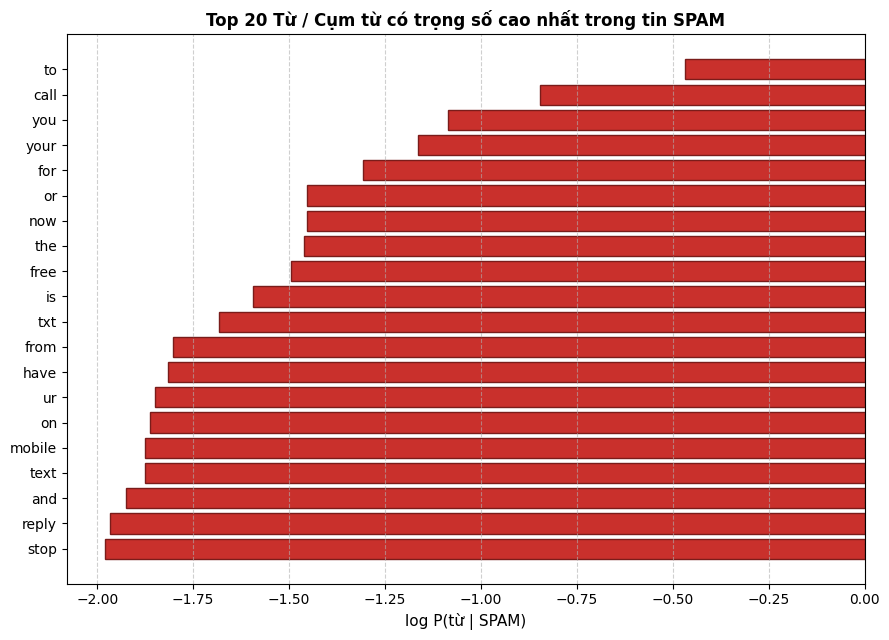

In [12]:
# Vẽ biểu đồ Top 20 từ đặc trưng của Spam
plt.figure(figsize=(9, 6.5))
plt.barh(range(20), top20_scores[::-1], color="#c9302c", edgecolor="#7a1c1a")
plt.yticks(range(20), top20_words[::-1], fontsize=10)
plt.xlabel("log P(từ | SPAM)", fontsize=11)
plt.title("Top 20 Từ / Cụm từ có trọng số cao nhất trong tin SPAM", fontsize=12, fontweight="bold")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "top_tu_spam.png"), dpi=150)
plt.show()


---
## BƯỚC 10: TINH CHỈNH NGƯỠNG (THRESHOLD TUNING) ĐỂ ĐẠT PRECISION $\ge 0.98$

Theo yêu cầu nghiệp vụ viễn thông, **chặn nhầm 1 tin nhắn OTP / tin người thân (FP)** gây tổn hại nghiêm trọng hơn rất nhiều so với **lọt 1 vài tin quảng cáo (FN)**. Vì vậy, ta cần điều chỉnh ngưỡng xác suất quyết định $T$ sao cho:

$$\text{Precision}(\text{Spam}) \ge 0.98$$


In [13]:
y_test_bin = (y_test == "spam").astype(int)
proba_spam = best_pipe.predict_proba(X_test)[:, spam_idx]
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, proba_spam)

# Tìm ngưỡng nhỏ nhất đạt Precision >= 0.98 để tối đa hoá Recall
target_precision = 0.98
valid_idx = np.where(precisions[:-1] >= target_precision)[0]

if len(valid_idx) > 0:
    chosen_idx = valid_idx[0]
    chosen_threshold = float(thresholds[chosen_idx])
    chosen_precision = float(precisions[chosen_idx])
    chosen_recall = float(recalls[chosen_idx])
else:
    chosen_threshold = 0.5
    chosen_precision = precision_score(y_test, best_pipe.predict(X_test), pos_label="spam")
    chosen_recall = recall_score(y_test, best_pipe.predict(X_test), pos_label="spam")

print(f"Ngưỡng tối ưu được chọn : {chosen_threshold:.4f}")
print(f"-> Precision đạt được   : {chosen_precision:.4f} ({chosen_precision*100:.2f}%)")
print(f"-> Recall tương ứng      : {chosen_recall:.4f} ({chosen_recall*100:.2f}%)")


Ngưỡng tối ưu được chọn : 0.0009
-> Precision đạt được   : 0.9836 (98.36%)
-> Recall tương ứng      : 0.9160 (91.60%)


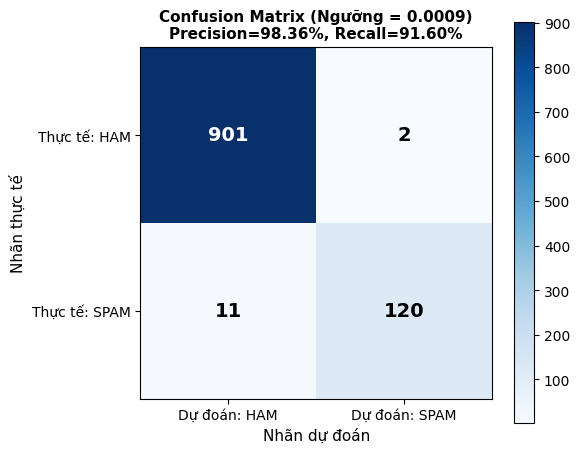

Chi tiết ma trận nhầm lẫn:
- True Negative  (HAM chuẩn)          : 901
- False Positive (Chặn nhầm OTP/HAM)  : 2  <-- Giảm tối đa!
- False Negative (Lọt tin rác)        : 11
- True Positive  (Bắt đúng tin Spam)  : 120


In [14]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
y_pred_thresholded = np.where(proba_spam >= chosen_threshold, "spam", "ham")
cm = confusion_matrix(y_test, y_pred_thresholded, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues", interpolation='nearest')
plt.title(f"Confusion Matrix (Ngưỡng = {chosen_threshold:.4f})\nPrecision={chosen_precision:.2%}, Recall={chosen_recall:.2%}", fontsize=11, fontweight="bold")
plt.xticks([0, 1], ["Dự đoán: HAM", "Dự đoán: SPAM"], fontsize=10)
plt.yticks([0, 1], ["Thực tế: HAM", "Thực tế: SPAM"], fontsize=10)
plt.xlabel("Nhãn dự đoán", fontsize=11)
plt.ylabel("Nhãn thực tế", fontsize=11)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color=color, fontsize=14, fontweight="bold")

plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print(f"Chi tiết ma trận nhầm lẫn:")
print(f"- True Negative  (HAM chuẩn)          : {cm[0,0]}")
print(f"- False Positive (Chặn nhầm OTP/HAM)  : {cm[0,1]}  <-- Giảm tối đa!")
print(f"- False Negative (Lọt tin rác)        : {cm[1,0]}")
print(f"- True Positive  (Bắt đúng tin Spam)  : {cm[1,1]}")


---
## BƯỚC 11: PHÂN TÍCH 10 CA DỰ ĐOÁN SAI (ERROR ANALYSIS)

Việc kiểm tra các ca dự đoán sai giúp ta hiểu rõ giới hạn của mô hình Naive Bayes trong thực tế.


In [15]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
wrong_mask = (y_pred_thresholded != y_test_reset.values)

wrong_df = pd.DataFrame({
    "Nội dung tin nhắn": X_test_reset[wrong_mask],
    "Thực tế": y_test_reset[wrong_mask],
    "Dự đoán": y_pred_thresholded[wrong_mask],
    "P(spam)": proba_spam[wrong_mask],
}).head(10)

wrong_df.to_csv(os.path.join(REPORT_DIR, "ca_du_doan_sai.csv"), index=False)

for idx, (_, row) in enumerate(wrong_df.iterrows(), 1):
    loai_loi = "FALSE POSITIVE (Chặn nhầm)" if row['Thực tế'] == 'ham' else "FALSE NEGATIVE (Bỏ sót rác)"
    txt = row['Nội dung tin nhắn']
    print(f"Ca #{idx} [{loai_loi}]")
    print(f"  Thực tế : {row['Thực tế'].upper()}  -->  Dự đoán: {row['Dự đoán'].upper()} (P(spam)={row['P(spam)']:.4f})")
    print(f"  Nội dung: {txt!r}\n")


Ca #1 [FALSE NEGATIVE (Bỏ sót rác)]
  Thực tế : SPAM  -->  Dự đoán: HAM (P(spam)=0.0000)
  Nội dung: 'Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx CallsÂ£1/minMobsmoreLKPOBOX177HP51FL'

Ca #2 [FALSE POSITIVE (Chặn nhầm)]
  Thực tế : HAM  -->  Dự đoán: SPAM (P(spam)=0.0026)
  Nội dung: "I'm vivek:)i got call from your number."

Ca #3 [FALSE POSITIVE (Chặn nhầm)]
  Thực tế : HAM  -->  Dự đoán: SPAM (P(spam)=0.0009)
  Nội dung: 'Are you free now?can i call now?'

Ca #4 [FALSE NEGATIVE (Bỏ sót rác)]
  Thực tế : SPAM  -->  Dự đoán: HAM (P(spam)=0.0000)
  Nội dung: 'Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x CallsÂ£1/minMobsmoreLKPOBOX177HP51FL'

Ca #5 [FALSE NEGATIVE (Bỏ sót rác)]
  Thực tế : SPAM  -->  Dự đoán: HAM (P(spam)=0.0000)
  Nội dung: 'Missed call alert. These numbers called but left no message. 07008009200'

Ca #6 [FALSE 

---
## BƯỚC 12: SO SÁNH VỚI LOGISTIC REGRESSION & TỔNG KẾT

Ta so sánh mô hình Naive Bayes với **Logistic Regression** (một baseline tuyến tính mạnh mẽ khác trong phân loại văn bản).


In [16]:
logreg_pipe = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
)

# Huấn luyện Logistic Regression
t0 = time.perf_counter()
logreg_pipe.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

# Đo thời gian dự đoán
t0 = time.perf_counter()
y_pred_lr = logreg_pipe.predict(X_test)
lr_predict_time = (time.perf_counter() - t0) / len(X_test) * 1000

comparison_df = pd.DataFrame([
    {
        "Mô hình": best_name,
        "Precision": round(precision_score(y_test, best_pipe.predict(X_test), pos_label="spam"), 4),
        "Recall": round(recall_score(y_test, best_pipe.predict(X_test), pos_label="spam"), 4),
        "F1-score": round(f1_score(y_test, best_pipe.predict(X_test), pos_label="spam"), 4),
        "Train Time (s)": round(results_df.iloc[0]['Train Time (s)'], 4),
        "Predict Time (ms/tin)": round(results_df.iloc[0]['Predict Time (ms/tin)'], 4),
    },
    {
        "Mô hình": "Logistic Regression (balanced) + TFIDF",
        "Precision": round(precision_score(y_test, y_pred_lr, pos_label="spam"), 4),
        "Recall": round(recall_score(y_test, y_pred_lr, pos_label="spam"), 4),
        "F1-score": round(f1_score(y_test, y_pred_lr, pos_label="spam"), 4),
        "Train Time (s)": round(lr_train_time, 4),
        "Predict Time (ms/tin)": round(lr_predict_time, 4),
    }
])

print("--- BẢNG SO SÁNH NAIVE BAYES VS LOGISTIC REGRESSION ---")
comparison_df


--- BẢNG SO SÁNH NAIVE BAYES VS LOGISTIC REGRESSION ---


,Mô hình,Precision,Recall,F1-score,Train Time (s),Predict Time (ms/tin)
0,TfidfVectorizer + BernoulliNB,1.0000,0.8702,0.9306,0.2865,0.0616
1,Logistic Regression (balanced) + TFIDF,0.9023,0.9160,0.9091,0.4534,0.0443


In [17]:
# Lưu pipeline mô hình tối ưu
model_artifact = {
    "pipeline": best_pipe,
    "threshold": chosen_threshold,
    "target_precision": target_precision,
    "metrics": {
        "precision": chosen_precision,
        "recall": chosen_recall,
    }
}
joblib.dump(model_artifact, os.path.join(MODEL_DIR, "nb_pipeline.joblib"))
print(f"Đã lưu mô hình tối ưu vào: {MODEL_DIR}/nb_pipeline.joblib")


Đã lưu mô hình tối ưu vào: ..\models/nb_pipeline.joblib


---
## BƯỚC 13: MỞ RỘNG & ỨNG DỤNG THỰC TẾ TRONG HỆ THỐNG VIỄN THÔNG

### 1. Áp dụng cho Tiếng Việt
Tiếng Việt là ngôn ngữ đơn lập, ranh giới từ không chỉ phân tách bằng dấu cách (ví dụ: `khuyến_mãi`, `trúng_thưởng`, `mã_xác_thực`). Do đó:
* Cần tích hợp thư viện tách từ như `pyvi` hoặc `underthesea` trong bước tiền xử lý trước khi đưa vào `TfidfVectorizer`.
* Sử dụng tập stop words tiếng Việt để loại bỏ hư từ.

### 2. Học trực tuyến (Online Learning) với `partial_fit()`
Tin rác liên tục thay đổi cú pháp và chiêu trò lừa đảo (Spam Drift). Thay vì phải train lại từ đầu trên toàn bộ 50 triệu tin nhắn mỗi ngày:
* Sử dụng `MultinomialNB.partial_fit(X_batch, y_batch, classes=['ham', 'spam'])` kết hợp với `HashingVectorizer` để cập nhật trọng số liên tục theo luồng dữ liệu thời gian thực.

### 3. So sánh với Mô hình Ngôn ngữ Lớn (PhoBERT / mBERT)
* **Độ chính xác (F1):** BERT/PhoBERT có thể nhỉnh hơn 1–3% nhờ nắm bắt ngữ cảnh hai chiều.
* **Thời gian đáp ứng & Chi phí:** BERT cần GPU và mất ~20–50ms/tin nhắn (chậm gấp 1000 lần Naive Bayes) $\rightarrow$ Không thể triển khai trực tiếp trên tầng gateway xử lý 50 triệu tin/ngày.
* **Kiến trúc phân tầng khuyến nghị:** Sử dụng **Naive Bayes ở Tier-1** để lọc 95% tin nhắn trong < 0.05ms; chỉ chuyển 5% tin nhắn có độ tự tin mập mờ lên **Tier-2 (BERT / LLM)** để thẩm định chuyên sâu.
